In [12]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
from go_ml.eval_utils import (gen_annot_mat, gen_seq_len_mask,
                              mean_reciprocal_rank, mean_reciprocal_rank_mat,
                                mean_auc, top_30_score, roc_average, bulk_auc)
from go_ml.eval_utils import filter_annot_df
data_root = '../gen_datasets/datasets'
csa_df = filter_annot_df(pd.read_csv(f'{data_root}/csa_annot.csv', sep='\t'))
llps_df = filter_annot_df(pd.read_csv(f'{data_root}/llps_dataset.csv', sep='\t'))
elms_df = filter_annot_df(pd.read_csv(f'{data_root}/elms_dataset.csv', sep='\t'))
ds_labels = ['csa', 'llps', 'elms']

eval_dict = {}

df_rows = []
import pickle
for ds_label, annot_df in zip(ds_labels, [csa_df, llps_df, elms_df]):
    annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
    seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
    eval_dict[ds_label] = {'annot_mat': annot_mat, 'seq_len_mask': seq_len_mask}
    np.random.seed(42)
    eval_dict[ds_label]['train_mask'] = np.random.rand(len(annot_df)) > 0.5
    
for fp in os.listdir('eval_files'):
    if not fp.endswith('.pkl'):
        continue
    save_str = fp.split('.pkl')[0]
    ds_label, model_name = save_str.split('_', 1)
    with open(f'eval_files/{fp}', 'rb') as f:
        pred_dict = pickle.load(f)
    eval_dict[ds_label][model_name] = pred_dict

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
pssm_mrr, bert_mrr, pssm_auc, bert_auc = [], [], [], []
pssm_top30, bert_top30 = [], []
pssm_roc, bert_roc = [], []

for ds_label in eval_dict.keys():
    row = eval_dict[ds_label]
    # mask = np.ones(len(row['annot_mat']), dtype=bool)
    mask = ~row['train_mask']
    annot_mat = row['annot_mat'][mask]
    seq_len_mask = row['seq_len_mask'][mask]

    bert_entropy = row['esm_esm2']['bert_entropy'][mask]
    bert_entropy_cond = row['esm_cond']['bert_entropy'][mask]
    bert_entropy_cond_baseline = row['esm_cond_baseline']['bert_entropy'][mask]
    bert_entropy_cond_span = row['esm_cond_span']['bert_entropy'][mask]
    bert_entropy_cond_span_baseline = row['esm_cond_span_baseline']['bert_entropy'][mask]
    pssm_entropy = row['msa']['pssm_entropy'][mask]
    ig_attr = row['ig_attr']['attribution_scores'][mask]
    score_pred = row['score_pred']['score_mat'][mask]

    score_dict = {
        'bert_entropy': 3 - bert_entropy,
        'bert_entropy_cond': 3 - bert_entropy_cond,
        'bert_entropy_cond_baseline': 3 - bert_entropy_cond_baseline,
        'bert_entropy_cond_span': 3 - bert_entropy_cond_span,
        'bert_entropy_cond_span_baseline': 3 - bert_entropy_cond_span_baseline,
        'pssm_entropy': 3 - pssm_entropy,
        'cond_entropy_gain': (bert_entropy_cond - bert_entropy),
        'cond_entropy_gain_span': (bert_entropy_cond_span - bert_entropy_cond_span_baseline),
        'ig_attr': ig_attr,
        'score_pred': score_pred
    }

    for annot_name, score_mat in score_dict.items():
        mrr = mean_reciprocal_rank_mat(score_mat, seq_len_mask, annot_mat)
        auc, fpr_l, tpr_l = mean_auc(score_mat, seq_len_mask, annot_mat, return_roc=True)
        top30 = top_30_score(score_mat, seq_len_mask, annot_mat)
        bauc = bulk_auc(score_mat, seq_len_mask, annot_mat)
        print(f"Dataset: {ds_label} {annot_name}, MRR: {mrr:.4f}, AUC: {auc:.4f}, BAUC: {bauc:.4f}, Top-30 Score: {top30:.4f}")
    print()

Dataset: csa bert_entropy, MRR: 0.0477, AUC: 0.8209, BAUC: 0.7949, Top-30 Score: 0.5827
Dataset: csa bert_entropy_cond, MRR: 0.0426, AUC: 0.8203, BAUC: 0.7930, Top-30 Score: 0.5748
Dataset: csa bert_entropy_cond_baseline, MRR: 0.0455, AUC: 0.8199, BAUC: 0.7927, Top-30 Score: 0.5782
Dataset: csa bert_entropy_cond_span, MRR: 0.0438, AUC: 0.8187, BAUC: 0.7964, Top-30 Score: 0.5778
Dataset: csa bert_entropy_cond_span_baseline, MRR: 0.0396, AUC: 0.8193, BAUC: 0.7939, Top-30 Score: 0.5797
Dataset: csa pssm_entropy, MRR: 0.0474, AUC: 0.8110, BAUC: 0.7794, Top-30 Score: 0.4379
Dataset: csa cond_entropy_gain, MRR: 0.0548, AUC: 0.6027, BAUC: 0.5844, Top-30 Score: 0.0829
Dataset: csa cond_entropy_gain_span, MRR: 0.0512, AUC: 0.4844, BAUC: 0.4804, Top-30 Score: 0.0534
Dataset: csa ig_attr, MRR: 0.0431, AUC: 0.4755, BAUC: 0.5419, Top-30 Score: 0.0866
Dataset: csa score_pred, MRR: 0.0494, AUC: 0.8326, BAUC: 0.8173, Top-30 Score: 0.6102

Dataset: llps bert_entropy, MRR: 0.3786, AUC: 0.4980, BAUC: 0.5

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
from go_ml.eval_utils import (gen_annot_mat, gen_seq_len_mask,
                              mean_reciprocal_rank, mean_reciprocal_rank_mat,
                                mean_auc, top_30_score, roc_average)
from go_ml.eval_utils import filter_annot_df
data_root = '../gen_datasets/datasets'
csa_df = filter_annot_df(pd.read_csv(f'{data_root}/csa_annot.csv', sep='\t'))
llps_df = filter_annot_df(pd.read_csv(f'{data_root}/llps_dataset.csv', sep='\t'))
elms_df = filter_annot_df(pd.read_csv(f'{data_root}/elms_dataset.csv', sep='\t'))
ds_labels = ['csa', 'llps', 'elms']

df_rows = []
import pickle
for ds_label, annot_df in zip(ds_labels, [csa_df, llps_df, elms_df]):
    annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
    seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
    
    with open(f'eval_files/{ds_label}_esmc.pkl', 'rb') as f:
        rd = pickle.load(f)
    df_row = {'annot_mat': annot_mat, 'seq_len_mask': seq_len_mask, 
              'bert_entropy': rd['bert_entropy'], 'bert_mat': rd['bert_mat']}
    
    with open(f'eval_files/{ds_label}_esm_fast.pkl', 'rb') as f:
        rd = pickle.load(f)
    df_row.update({'bert_entropy_fast': rd['bert_entropy'], 'bert_mat_fast': rd['bert_mat']})

    with open(f'eval_files/{ds_label}_esm_esm2.pkl', 'rb') as f:
        rd = pickle.load(f)
    df_row.update({'bert_entropy_esm2': rd['bert_entropy'], 'bert_mat_esm2': rd['bert_mat']})

    with open(f'eval_files/{ds_label}_esm_fast_esm2.pkl', 'rb') as f:
        rd = pickle.load(f)
    df_row.update({'bert_entropy_esm2_fast': rd['bert_entropy'], 'bert_mat_esm2_fast': rd['bert_mat']})

    with open(f'eval_files/{ds_label}_esm_cond.pkl', 'rb') as f:
        rd = pickle.load(f)
    df_row.update({'bert_entropy_esm_cond': rd['bert_entropy'], 'bert_mat_esm_cond': rd['bert_mat']})

    with open(f'eval_files/{ds_label}_esm_cond_baseline.pkl', 'rb') as f:
        rd = pickle.load(f)
    df_row.update({'bert_entropy_esm_cond_baseline': rd['bert_entropy'], 'bert_mat_esm_cond_baseline': rd['bert_mat']})

    with open(f'eval_files/{ds_label}_msa.pkl', 'rb') as f:
        rd = pickle.load(f)
    df_row.update({'pssm_entropy': rd['pssm_entropy'], 'pssm_mat': rd['pssm']})

    if os.path.exists(f'eval_files/{ds_label}_scan_idx.pkl'):
        with open(f'eval_files/{ds_label}_scan_idx.pkl', 'rb') as f:
            rd = pickle.load(f)
        df_row.update({'scan_logits': rd['scan_logits']})
    else:
        df_row.update({'scan_logits': None,})

    if os.path.exists(f'eval_files/{ds_label}_ig_attr.pkl'):
        with open(f'eval_files/{ds_label}_ig_attr.pkl', 'rb') as f:
            rd = pickle.load(f)
        df_row.update({'ig_attribution_scores': rd['attribution_scores'], 'ig_attribution_mat': rd['attribution_mat']})
    else:
        df_row.update({'ig_attribution_scores': None, 'ig_attribution_mat': None})

    df_rows.append(df_row)
eval_df = pd.DataFrame(df_rows, index=ds_labels)    

In [4]:
pssm_mrr, bert_mrr, pssm_auc, bert_auc = [], [], [], []
pssm_top30, bert_top30 = [], []
pssm_roc, bert_roc = [], []

for row in eval_df.iterrows():
    ds_label = row[0]
    row = row[1]  # Get the row data
    annot_mat = row['annot_mat']
    seq_len_mask = row['seq_len_mask']
    bert_entropy = row['bert_entropy']
    bert_entropy_fast = row['bert_entropy_fast']
    bert_entropy_esm2 = row['bert_entropy_esm2']
    bert_entropy_esm2_fast = row['bert_entropy_esm2_fast']

    pssm_entropy = row['pssm_entropy']
    ig_attribution_scores = row['ig_attribution_scores']
    # scan_scores = row['scan_scores']
    # print(annot_mat.shape, seq_len_mask.shape, bert_entropy.shape, pssm_entropy.shape)
    
    mrr = mean_reciprocal_rank_mat(3 - bert_entropy, seq_len_mask, annot_mat)
    auc, fpr_l, tpr_l = mean_auc(3 - bert_entropy, seq_len_mask, annot_mat, return_roc=True)
    top30 = top_30_score(3 - bert_entropy, seq_len_mask, annot_mat)
    bert_mrr.append(mrr); bert_auc.append(auc); bert_top30.append(top30)
    bert_roc.append(roc_average(fpr_l, tpr_l))

    print(f"Dataset: {ds_label} (BERT), MRR: {mrr:.4f}, AUC: {auc:.4f}, Top-30 Score: {top30:.4f}")

    mrr = mean_reciprocal_rank_mat(3 - bert_entropy_fast, seq_len_mask, annot_mat)
    auc, fpr_l, tpr_l = mean_auc(3 - bert_entropy_fast, seq_len_mask, annot_mat, return_roc=True)
    top30 = top_30_score(3 - bert_entropy_fast, seq_len_mask, annot_mat)
    bert_mrr.append(mrr); bert_auc.append(auc); bert_top30.append(top30)
    bert_roc.append(roc_average(fpr_l, tpr_l))

    print(f"Dataset: {ds_label} (BERT-fast), MRR: {mrr:.4f}, AUC: {auc:.4f}, Top-30 Score: {top30:.4f}")

    mrr = mean_reciprocal_rank_mat(3 - bert_entropy_esm2, seq_len_mask, annot_mat)
    auc, fpr_l, tpr_l = mean_auc(3 - bert_entropy_esm2, seq_len_mask, annot_mat, return_roc=True)
    top30 = top_30_score(3 - bert_entropy_esm2, seq_len_mask, annot_mat)
    bert_mrr.append(mrr); bert_auc.append(auc); bert_top30.append(top30)
    bert_roc.append(roc_average(fpr_l, tpr_l))

    print(f"Dataset: {ds_label} (BERT-ESM2), MRR: {mrr:.4f}, AUC: {auc:.4f}, Top-30 Score: {top30:.4f}")

    mrr = mean_reciprocal_rank_mat(3 - bert_entropy_esm2_fast, seq_len_mask, annot_mat)
    auc, fpr_l, tpr_l = mean_auc(3 - bert_entropy_esm2_fast, seq_len_mask, annot_mat, return_roc=True)
    top30 = top_30_score(3 - bert_entropy_esm2_fast, seq_len_mask, annot_mat)
    bert_mrr.append(mrr); bert_auc.append(auc); bert_top30.append(top30)
    bert_roc.append(roc_average(fpr_l, tpr_l))

    print(f"Dataset: {ds_label} (BERT-ESM2-Fast), MRR: {mrr:.4f}, AUC: {auc:.4f}, Top-30 Score: {top30:.4f}")


    mrr = mean_reciprocal_rank_mat(3 - pssm_entropy, seq_len_mask, annot_mat)
    auc, fpr_l, tpr_l = mean_auc(3 - pssm_entropy, seq_len_mask, annot_mat, return_roc=True)
    top30 = top_30_score(3 - pssm_entropy, seq_len_mask, annot_mat)
    
    pssm_mrr.append(mrr); pssm_auc.append(auc); pssm_top30.append(top30)
    pssm_roc.append(roc_average(fpr_l, tpr_l))
    print(f"Dataset: {ds_label} (PSSM), MRR: {mrr:.4f}, AUC: {auc:.4f}, Top-30 Score: {top30:.4f}")

    if(ig_attribution_scores is not None):
        mrr = mean_reciprocal_rank_mat(ig_attribution_scores, seq_len_mask, annot_mat)
        auc, fpr_l, tpr_l = mean_auc(ig_attribution_scores, seq_len_mask, annot_mat, return_roc=True)
        top30 = top_30_score(ig_attribution_scores, seq_len_mask, annot_mat)
        print(f"Dataset: {ds_label} (IG Attributions), MRR: {mrr:.4f}, AUC: {auc:.4f}, Top-30 Score: {top30:.4f}")

    # if(scan_scores is not None):
    #     mrr = mean_reciprocal_rank_mat(scan_scores, seq_len_mask, annot_mat)
    #     auc, fpr_l, tpr_l = mean_auc(scan_scores, seq_len_mask, annot_mat, return_roc=True)
    #     top30 = top_30_score(scan_scores, seq_len_mask, annot_mat)
    #     print(f"Dataset: {ds_label} (Scan Scores), MRR: {mrr:.4f}, AUC: {auc:.4f}, Top-30 Score: {top30:.4f}")

    #     diff_score = scan_scores - bert_entropy
    #     mrr = mean_reciprocal_rank_mat(diff_score, seq_len_mask, annot_mat)
    #     auc, fpr_l, tpr_l = mean_auc(diff_score, seq_len_mask, annot_mat, return_roc=True)
    #     scan_fpr, scan_tpr = roc_average(fpr_l, tpr_l)
    #     scan_fpr_l, scan_tpr_l = fpr_l, tpr_l
    #     top30 = top_30_score(diff_score, seq_len_mask, annot_mat)
    #     print(f"Dataset: {ds_label} (Scan - BERT), MRR: {mrr:.4f}, AUC: {auc:.4f}, Top-30 Score: {top30:.4f}")
    


Dataset: csa (BERT), MRR: 0.0508, AUC: 0.8158, Top-30 Score: 0.5966
Dataset: csa (BERT-fast), MRR: 0.0445, AUC: 0.7765, Top-30 Score: 0.4496
Dataset: csa (BERT-ESM2), MRR: 0.0455, AUC: 0.8077, Top-30 Score: 0.5727
Dataset: csa (BERT-ESM2-Fast), MRR: 0.0421, AUC: 0.8085, Top-30 Score: 0.5703
Dataset: csa (PSSM), MRR: 0.0449, AUC: 0.7943, Top-30 Score: 0.4198
Dataset: csa (IG Attributions), MRR: 0.0517, AUC: 0.4779, Top-30 Score: 0.0843
Dataset: llps (BERT), MRR: 0.4769, AUC: 0.4500, Top-30 Score: 0.2976
Dataset: llps (BERT-fast), MRR: 0.4696, AUC: 0.4592, Top-30 Score: 0.2826
Dataset: llps (BERT-ESM2), MRR: 0.4284, AUC: 0.4900, Top-30 Score: 0.2955
Dataset: llps (BERT-ESM2-Fast), MRR: 0.4321, AUC: 0.4890, Top-30 Score: 0.2971
Dataset: llps (PSSM), MRR: 0.3273, AUC: 0.3809, Top-30 Score: 0.2448
Dataset: llps (IG Attributions), MRR: 0.4526, AUC: 0.4794, Top-30 Score: 0.3409
Dataset: elms (BERT), MRR: 0.0418, AUC: 0.5231, Top-30 Score: 0.0938
Dataset: elms (BERT-fast), MRR: 0.0685, AUC: 0.

In [24]:
#Add eval data columns to eval_df
eval_df = eval_df.assign(
    pssm_mrr=pssm_mrr, bert_mrr=bert_mrr,
    pssm_auc=pssm_auc, bert_auc=bert_auc,
    pssm_top30=pssm_top30, bert_top30=bert_top30,
    pssm_roc=pssm_roc, bert_roc=bert_roc)

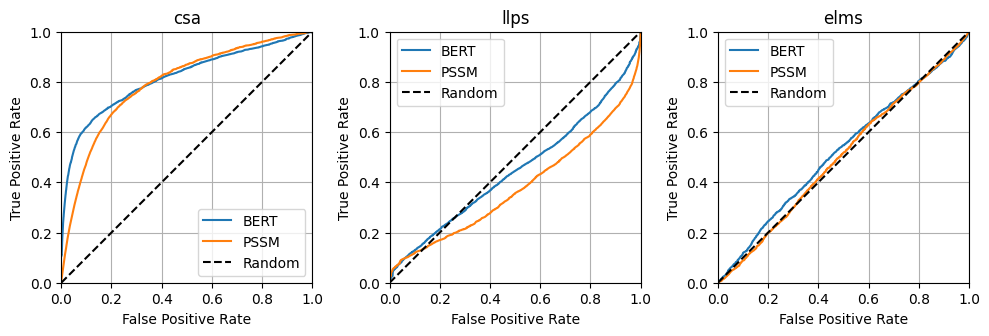

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
for i, ds_label in enumerate(ds_labels):
    ax = axes[i]
    fpr, tpr = eval_df.loc[ds_label]['bert_roc']
    ax.plot(fpr, tpr, label='BERT')
    fpr, tpr = eval_df.loc[ds_label]['pssm_roc']
    ax.plot(fpr, tpr, label='PSSM')
    ax.plot([0, 1], [0, 1], 'k--', label='Random')
    ax.set_title(ds_label)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid()
    ax.set_aspect('equal')
    ax.legend()
fig.tight_layout()